In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.metrics import confusion_matrix,precision_score,recall_score,accuracy_score,f1_score

In [2]:
df=pd.read_csv('loan_approval_dataset.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 531.6 KB


In [4]:
x = df.drop(columns=[' loan_status'])
y = df[' loan_status']

In [5]:
xtrain, xtest, ytrain, ytest = train_test_split(
    x,
    y,
    train_size=0.8,
    random_state=42
)

In [6]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [7]:
cat_cols = x.select_dtypes(include='object').columns
# df[cat_cols].unique() #OneHotEncoder

C:\Users\ANUSHKA SAHA\AppData\Local\Temp\ipykernel_27856\2011958109.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = x.select_dtypes(include='object').columns


In [8]:
num_cols = x.select_dtypes(include = 'number').columns

<Axes: >

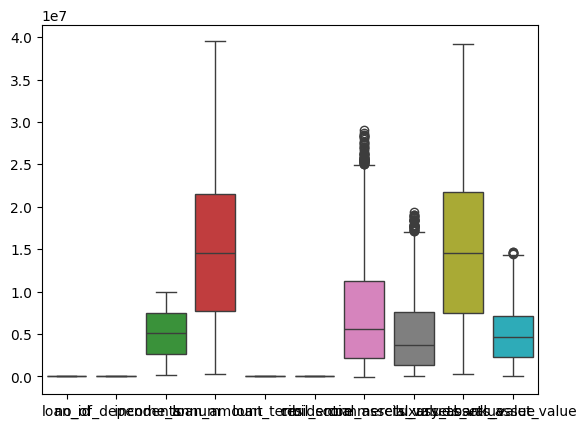

In [9]:
sns.boxplot(df[num_cols])

In [10]:
preprocessing = ColumnTransformer(
    transformers = [
        ('scaling',MinMaxScaler(),num_cols),
        ('encoder',OneHotEncoder(handle_unknown='ignore'),cat_cols)
    ]
)
# preprocessing

In [11]:
main_pipeline = Pipeline(
     steps=[
        ('pre',preprocessing),
        # ('model',LogisticRegression(penalty='l1',solver='lbfgs')),  #Value Error
        ('model',LogisticRegression(penalty='l1',solver='liblinear')),
        # ('model',LogisticRegression(penalty='l1',solver='sag')), #Value Error
      #   ('model',LogisticRegression(penalty='l1',solver='saga')),

      #   ('model',LogisticRegression(penalty='l2',solver='lbfgs')),
      #   ('model',LogisticRegression(penalty='l2',solver='liblinear')),
      #   ('model',LogisticRegression(penalty='l2',solver='sag')),
      #   ('model',LogisticRegression(penalty='l2',solver='saga')),

        # ('model',LogisticRegression(penalty='elasticnet',solver='lbfgs')), #Value Error
        # ('model',LogisticRegression(penalty='elasticnet',solver='liblinear')), #Value Error
        # ('model',LogisticRegression(penalty='elasticnet',solver='sag')), #Value Error
      #   ('model',LogisticRegression(penalty='elasticnet',solver='saga')),

      #   ('model',LogisticRegression(penalty=None,solver='lbfgs')),
        # ('model',LogisticRegression(penalty=None,solver='liblinear')), #Value Error
      #   ('model',LogisticRegression(penalty=None,solver='sag')),
      #   ('model',LogisticRegression(penalty=None,solver='saga'))

        
     ]
)
main_pipeline.fit(xtrain,ytrain)

c:\Users\ANUSHKA SAHA\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ANUSHKA SAHA\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","[' Approved',' Rejected']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['loan_id',' no_of_dependents',' education',...,' commercial_assets_value', ' luxury_assets_value',' bank_asset_value']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaling', ...), ('encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (de

In [12]:
#model creation
# model = LogisticRegression()
# model.fit(xtrain,ytrain)

## Classification Metrics

#### Confusion Matrix

In [13]:
ytrain.value_counts()

 loan_status
Approved    2120
Rejected    1295
Name: count, dtype: int64

#### Train Data

In [14]:
ytrain_pred = main_pipeline.predict(xtrain)
cm_train = confusion_matrix(ytrain,ytrain_pred)
cm_train

array([[1985,  135],
       [ 140, 1155]])

##### Test Data

In [15]:
ytest_pred = main_pipeline.predict(xtest)
cm_test = confusion_matrix(ytest,ytest_pred)
cm_test

array([[498,  38],
       [ 43, 275]])

#### Precision Score For Yes

#### Train Data


In [16]:
precision_score(ytrain,ytrain_pred,pos_label=' Approved')

0.9341176470588235

In [17]:
cm_train

array([[1985,  135],
       [ 140, 1155]])

In [18]:
cm_train[:,1].sum() #:-->all rows,1:-->cols

np.int64(1290)

##### Out of all the Predicted 425 Approved label,54% labels are correctly predicted as Approved

##### Out of all the Predicted 425 Approved,46% labels are correctly predicted as Approved

#### Test Data

In [19]:
ytest_predicted = main_pipeline.predict(xtest)
precision_score(ytest,ytest_pred,pos_label=' Approved')

0.9205175600739371

#### Precision Score For No

#### Train Data

In [21]:
precision_score(ytrain,ytrain_pred,pos_label=' Rejected')

0.8953488372093024

In [22]:
cm_train

array([[1985,  135],
       [ 140, 1155]])

In [23]:
cm_train[:,0].sum()

np.int64(2125)

##### Out of all the Predicted 375 No label,54% labels are correctly predicted as No

##### Out of all the Predicted 375 No label,46% labels are correctly predicted as No

#### Test Data

In [24]:
ytest_predicted = main_pipeline.predict(xtest)
precision_score(ytest,ytest_pred,pos_label=' Rejected')

0.8785942492012779